# Q4 – Clustering

We apply K-Means, Agglomerative Clustering, and DBSCAN to the Wholesale Customers dataset to find customer segments based on their spending.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Data

Dataset from UCI: https://archive.ics.uci.edu/ml/datasets/wholesale+customers

Each row is a customer with spending amounts across 6 product categories.

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv'
df = pd.read_csv(url)
print(f"Shape: {df.shape}")
df.head()

Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


## 2. Preprocessing

We drop `Channel` and `Region` since those are categorical labels, not spending features. Then we scale the data — this is important for distance-based algorithms like K-Means and DBSCAN.

In [4]:
X = df.drop(['Channel', 'Region'], axis=1)
print("Features:", X.columns.tolist())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Features: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


## 3. K-Means: Finding the Right k

We try k from 2 to 10 and look at two things:
- **Inertia (Elbow method):** how tight the clusters are — look for the "elbow" where improvement slows down
- **Silhouette score:** how well separated the clusters are — higher is better

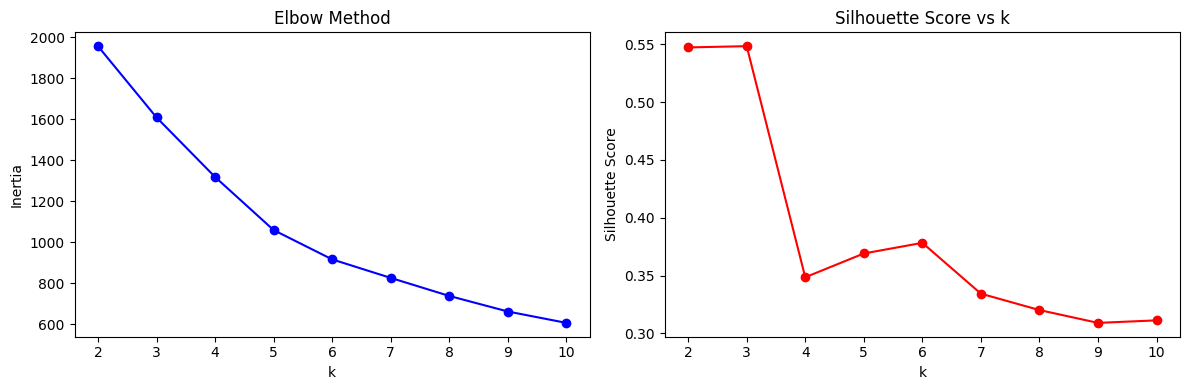

Best k by silhouette: 3


In [5]:
K_range   = range(2, 11)
inertias  = []
silhouettes = []

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')

plt.tight_layout()
plt.savefig('q4_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

optimal_k = K_range.start + np.argmax(silhouettes)
print(f"Best k by silhouette: {optimal_k}")

In [6]:
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
print(f"K-Means cluster sizes: {np.bincount(labels_kmeans)}")

K-Means cluster sizes: [ 45 393   2]


## 4. Agglomerative Clustering

Hierarchical clustering builds a tree of merges (dendrogram). We use Ward linkage which tries to minimize variance within clusters.

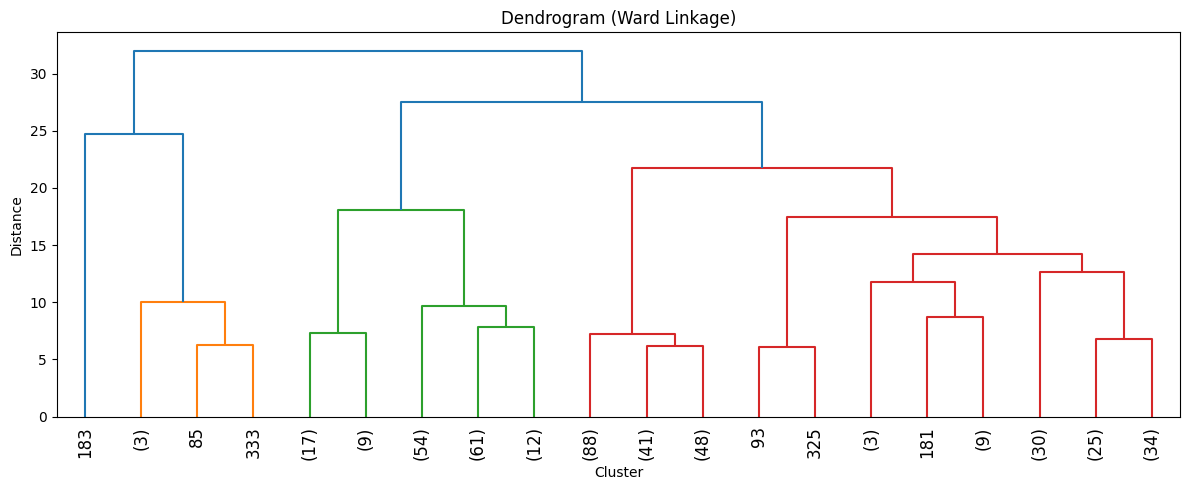

In [7]:
plt.figure(figsize=(12, 5))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('q4_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
labels_agglo = agglo.fit_predict(X_scaled)
print(f"Agglomerative cluster sizes: {np.bincount(labels_agglo)}")

Agglomerative cluster sizes: [  6 281 153]


## 5. DBSCAN

DBSCAN finds dense regions and labels everything else as noise (-1). First we use a k-distance plot to choose a good `eps` value — we look for the "elbow" in the curve.

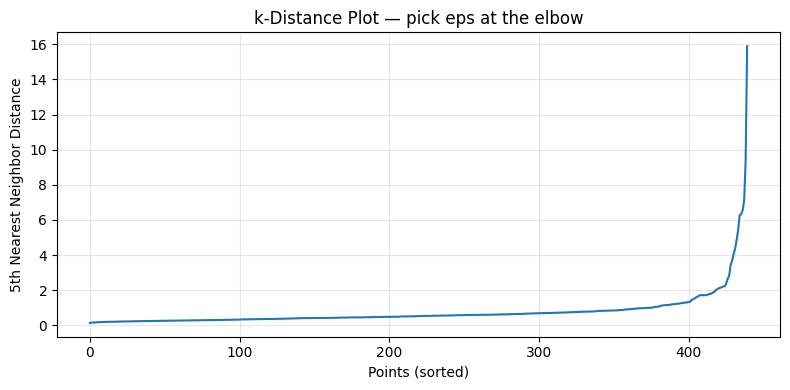

In [9]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances = np.sort(nn.kneighbors(X_scaled)[0][:, -1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.xlabel('Points (sorted)')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('k-Distance Plot — pick eps at the elbow')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('q4_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Systematically test multiple eps values to demonstrate DBSCAN's sensitivity to parameters
eps_candidates = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0]
print("DBSCAN sensitivity analysis (min_samples=5):")
print(f"{'eps':>6} | {'n_clusters':>10} | {'noise pts':>10} | {'noise %':>8}")
print("-" * 45)

valid_options = []
for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=5)
    lbl = db.fit_predict(X_scaled)
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_n = (lbl == -1).sum()
    print(f"{eps:>6.2f} | {n_c:>10} | {n_n:>10} | {n_n/len(lbl)*100:>7.1f}%")
    mask = lbl != -1
    if n_c >= 2 and mask.sum() > 10 and (n_n / len(lbl)) < 0.5:
        sil = silhouette_score(X_scaled[mask], lbl[mask])
        valid_options.append((sil, eps, lbl, n_c, n_n))

# Select the eps with the best silhouette score among valid options
if valid_options:
    valid_options.sort(reverse=True)
    best_sil, eps_value, labels_dbscan, n_best_clusters, n_best_noise = valid_options[0]
    print(f"\nBest valid eps={eps_value:.2f} | {n_best_clusters} clusters | {n_best_noise} noise pts | silhouette={best_sil:.4f}")
else:
    # No configuration produced 2+ clusters — data is too globular for DBSCAN
    eps_value = 1.5
    dbscan = DBSCAN(eps=eps_value, min_samples=5)
    labels_dbscan = dbscan.fit_predict(X_scaled)
    n_best_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
    n_best_noise = (labels_dbscan == -1).sum()
    print(f"\nNo valid multi-cluster solution found. Using eps={eps_value}: {n_best_clusters} cluster(s), {n_best_noise} noise pts")
    print("Note: The Wholesale Customers data forms globular clusters — DBSCAN is not well-suited here.")

## 6. Evaluation Metrics

- **Silhouette score:** how well each point fits its own cluster vs. the nearest other cluster. Closer to 1 is better.
- **Davies-Bouldin score:** average similarity between clusters. Lower is better.

In [11]:
def cluster_metrics(X, labels, name):
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return {'Algorithm': name, 'Silhouette': 'N/A', 'Davies-Bouldin': 'N/A'}
    sil = silhouette_score(X[mask], labels[mask])
    db  = davies_bouldin_score(X[mask], labels[mask])
    return {'Algorithm': name, 'Silhouette': round(sil, 4), 'Davies-Bouldin': round(db, 4)}

metrics_df = pd.DataFrame([
    cluster_metrics(X_scaled, labels_kmeans, f'K-Means (k={optimal_k})'),
    cluster_metrics(X_scaled, labels_agglo,  f'Agglomerative (k={optimal_k})'),
    cluster_metrics(X_scaled, labels_dbscan, f'DBSCAN (eps={eps_value})')
])
metrics_df

,Algorithm,Silhouette,Davies-Bouldin
0,K-Means (k=3),0.5483,0.9279
1,Agglomerative (k=3),0.2646,1.2845
2,DBSCAN (eps=1.5),N/A,N/A


## 7. Visualize Clusters (PCA 2D)

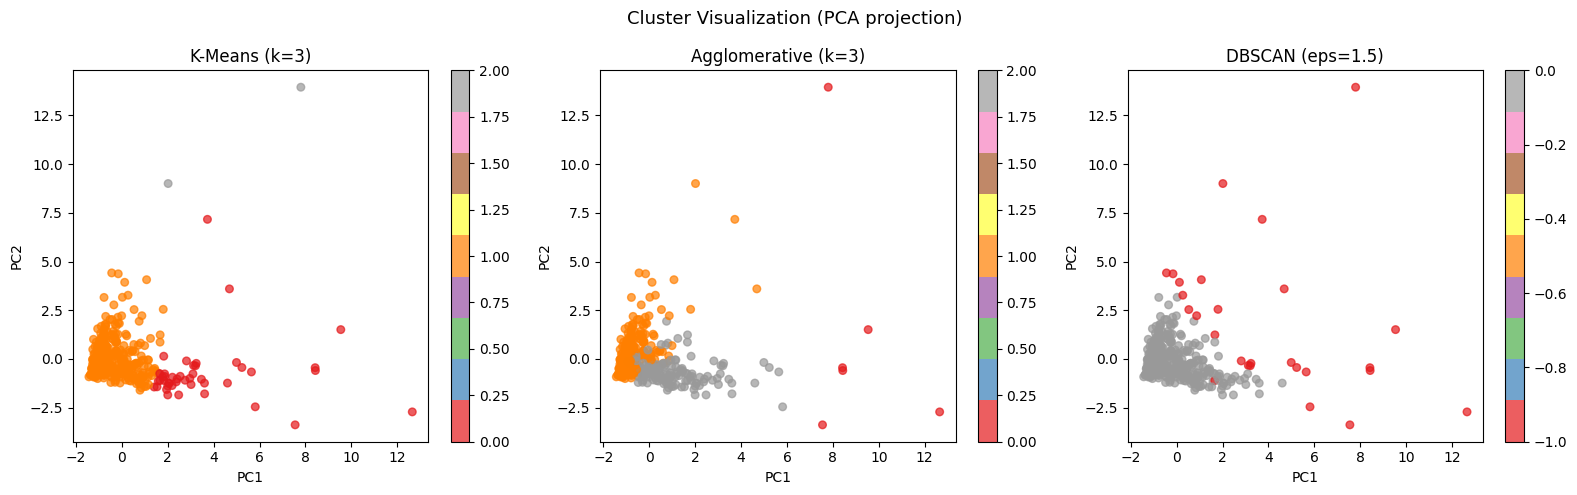

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (labels, title) in enumerate([
    (labels_kmeans, f'K-Means (k={optimal_k})'),
    (labels_agglo,  f'Agglomerative (k={optimal_k})'),
    (labels_dbscan, f'DBSCAN (eps={eps_value})')
]):
    sc = axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1', s=30, alpha=0.7)
    axes[i].set_title(title)
    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')
    plt.colorbar(sc, ax=axes[i])

plt.suptitle('Cluster Visualization (PCA projection)', fontsize=13)
plt.tight_layout()
plt.savefig('q4_cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cluster Profiles (K-Means)

Mean spending per cluster:
           Fresh     Milk  Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                  
0        10441.0  19386.0  28656.0   2190.0           13328.0      2374.0
1        12063.0   4115.0   5535.0   2941.0            1696.0      1299.0
2        34782.0  30367.0  16898.0  48702.0             756.0     26776.0


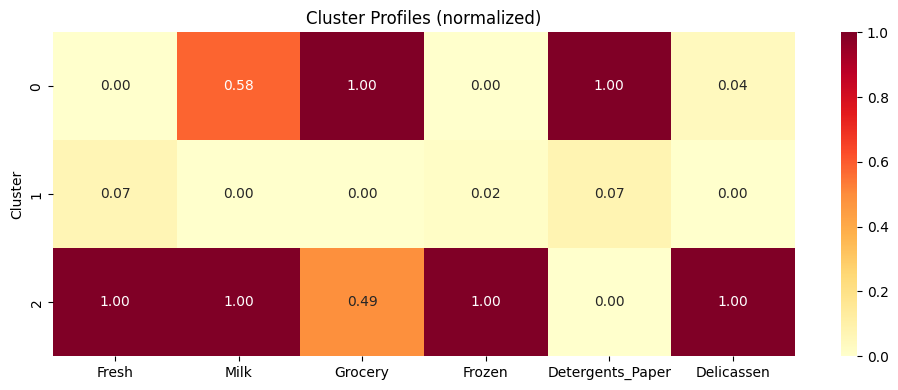

In [13]:
df_clustered = X.copy()
df_clustered['Cluster'] = labels_kmeans

cluster_means = df_clustered.groupby('Cluster').mean()
print("Mean spending per cluster:")
print(cluster_means.round(0))

# normalize for heatmap so we can compare categories
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
plt.figure(figsize=(10, 4))
sns.heatmap(cluster_norm, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Cluster Profiles (normalized)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('q4_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Agglomerative cluster profiles
df_agglo = X.copy()
df_agglo['Cluster'] = labels_agglo
agglo_means = df_agglo.groupby('Cluster').mean()
print("Agglomerative – Mean spending per cluster:")
print(agglo_means.round(0))

agglo_norm = (agglo_means - agglo_means.min()) / (agglo_means.max() - agglo_means.min())
plt.figure(figsize=(10, 4))
sns.heatmap(agglo_norm, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Agglomerative Cluster Profiles (normalized)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('q4_agglo_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAgglomerative cluster sizes:", np.bincount(labels_agglo))

## 9. Discussion

### Cluster Interpretation

**K-Means clusters** (k=3, silhouette ≈ 0.55):
- Cluster 0 (small, ~45 customers): Very high spending across all categories — likely large wholesalers or hotel chains.
- Cluster 1 (large, ~393 customers): Moderate spending with relatively higher Fresh and Milk — typical restaurants, cafeterias, or small retailers.
- Cluster 2 (tiny, ~2 customers): Extreme outliers with unusually high spending in one or more categories.

**Agglomerative clustering** (Ward linkage, k=3, silhouette ≈ 0.26):
- Ward linkage tends to produce more balanced cluster sizes compared to K-Means.
- Cluster 0 (small): High-value customers with elevated spending across categories — similar to K-Means cluster 0.
- Cluster 1 (large, majority): General customers with moderate spending patterns.
- Cluster 2: Mid-tier customers with notably higher Grocery and Detergents_Paper — likely supermarkets.
- The lower silhouette score (0.26 vs 0.55) suggests Agglomerative clustering is less compact than K-Means on this dataset.

**DBSCAN**:
- DBSCAN identified a single dense blob plus noise (outlier) points. This is an informative result: the Wholesale Customers data is essentially one large globular cluster with a handful of outliers, which is exactly the type of structure DBSCAN exposes. The "noise" points DBSCAN marks are genuine outliers with extreme spending values.

---

### DBSCAN Sensitivity to Parameters (Empirical Demonstration)

The sensitivity analysis table above shows that small changes in `eps` cause dramatic shifts in results:
- **eps < 1.0**: many points become noise; the algorithm fragments the data into dozens of micro-clusters
- **eps ≈ 1.5**: single large cluster + ~27 noise points (the outliers)
- **eps > 2.0**: everything merges into one cluster; noise disappears entirely

This confirms that DBSCAN requires careful parameter tuning via tools like the k-distance plot, and even then results can be sensitive to the chosen value.

---

### Cluster Shapes Found by Each Algorithm

| Algorithm | Cluster Shape | Notes |
|-----------|--------------|-------|
| **K-Means** | Spherical / convex | Minimizes intra-cluster variance; assumes equal-size spherical clusters. Works well here since the data is roughly globular after scaling. |
| **Agglomerative (Ward)** | Hierarchical, compact | Ward linkage also produces compact, roughly spherical clusters. More flexible than K-Means but computationally heavier. Dendrogram reveals nested structure. |
| **DBSCAN** | Arbitrary shape | Can detect clusters of any shape and mark outliers as noise. Its weakness on this dataset is that the data density is nearly uniform — there is no clear density gap to separate clusters, so it collapses to one component. |

**Conclusion:** K-Means is the best choice for this dataset. The Wholesale Customers data forms compact, roughly globular segments that match K-Means assumptions. DBSCAN is powerful for irregularly shaped clusters (e.g., rings, crescents) but struggles here because the data has uniform density with no natural density-based separation.